# Analysis of relation between Guardian coverage of geopolitical crises and commodity price action

# Contents

*Stuff to do*

- Contents structure
- How we carried out the analysis
- What are the tools used
- gitignore api key
- conclusion?
- proof

# 1. Introduction

Online media coverage of geopolitical crises is a major source of readily available information for traders globally. So commodity price action should be influenced by investor sentiment surrounding these published articles.

We know that the media shapes narratives around these markets which affects investor sentiment. Understanding how a major news outlet like the Guardian covers commonly traded commodities offers insight into the information environment that shapes public perception and potentially market behaviour. The Guardian is generally seen as a reliable and unbiased centre-left leaning news publisher, and we assume here that the publications released are factual and have no intention of steering the price of commodities any certain way. We are just aiming to see how their publications correlate with the markets.

Similar questions to do with how geopolitical events affect markets have obviously been researched before, but our project is unique in that we’re using the Guardian, a left-leaning news source, as our primary data source to measure against key energy commodities.

# 1.1 Research questions
1. Q1: How does coverage volume change around geopolitical events? (e.g. Iran war, Russia - Ukraine war, OPEC production decisions, COVID supply disruptions)?

2. Which commodities out of oil, gas, wheat and gold receive disproportionate media attention relative to others, and how has this composition shifted over time?

3. Is there a visible relationship between coverage and commodity prices?

# 2. Data Acquisition
- Our data range is from 1/1/2020 to 31/3/2026

Our primary data source is the Guardian API, using commodity-related search terms we collected date, section, title and body text
- We searched keywords such as brent oil, gold, natural gas, wheat, OPEC and energy crisis
- We scoured 20 articles in intervals of every week
- The keywords OPEC and energy crisis are most commonly associated with commodities and geopolitical tensions, since most of these wars are fought over oil which heavily affects energy prices globally.

Our secondary data source is commodity price data is sourced from yahoo finance, using the python package yfinance.
- Here we collected price and date on a weekly basis

In [2]:
import json
import requests
import pandas as pd
import time

# Load API key from keys.json
with open('keys.json') as f:
    key = json.load(f)

API_KEY = key['guardian']['api_key']
BASE_URL = 'https://content.guardianapis.com'

# Generate (Monday, Sunday) pairs for each week from Jan 2020 to Mar 2026
week_starts = pd.date_range("2020-01-01", "2026-03-31", freq="W-MON") # W-Mon: Weekly starting on Monday
date_ranges = []
for d in week_starts:
    start = d.strftime("%Y-%m-%d")  # parse the string as a date
    end = (d + pd.Timedelta(days=6)).strftime("%Y-%m-%d") # pd.Timedelta: adds 6 days to the date, so it starts on next week.
    date_ranges.append((start, end))

print(f"Total weeks to collect: {len(date_ranges)}")

all_results = []

for from_date, to_date in date_ranges:
    parameters = {
        "api-key": API_KEY,
        "q": "oil OR natural gas OR gold OR OPEC OR energy crisis OR wheat",
        "page-size": 20,   # fetch 20 articles per week
        "page": 1,
        "show-fields": "bodyText",
        "from-date": from_date,
        "to-date": to_date,
        "order-by": "relevance"
    }

    try:
        response = requests.get(f"{BASE_URL}/search", params=parameters)
        response.raise_for_status()
        data = response.json()['response']
    except Exception as e:
        print(f"  Error on {from_date}: {e}")
        continue

    for article in data['results']:
        all_results.append({
            'date': article.get('webPublicationDate'),
            'section': article.get('sectionName'),
            'title': article.get('webTitle'),
            'body': article.get('fields', {}).get('bodyText', '')
        })

    time.sleep(0.25)

print(f"Collection complete: {len(all_results)} articles collected")

df = pd.DataFrame(all_results)
df['date'] = pd.to_datetime(df['date'], utc=True)
df_raw = df.drop_duplicates(subset=['title']).reset_index(drop=True)
df_raw.to_csv('data/guardian_commodities.csv', index=False)
print(f"Done. {len(df_raw)} articles saved to data/guardian_commodities.csv")


# df_raw = pd.read_csv('data/guardian_commodities.csv')
print(f"Loaded {len(df_raw)} articles from Guardian API")

Total weeks to collect: 326
Collection complete: 6520 articles collected
Done. 6515 articles saved to data/guardian_commodities.csv
Loaded 6515 articles from Guardian API


In [3]:
# ---- Commodity price data from Yahoo Finance ----
import pandas as pd
import yfinance as yf

commodities = {
    "Gold":        "GC=F",
    "Brent Oil":   "BZ=F",
    "Natural Gas": "NG=F",
    "Wheat":       "ZW=F",
}

price_data = yf.download(
    tickers=list(commodities.values()),
    start="2020-01-01",
    end="2025-12-31",
    interval="1wk"
)

close_prices = price_data["Close"]
close_prices.columns = list(commodities.keys())

df_commodities_prices = pd.DataFrame(close_prices)
print(close_prices.head())

YF.download() has changed argument auto_adjust default to True


[*********************100%***********************]  4 of 4 completed

                 Gold    Brent Oil  Natural Gas   Wheat
Date                                                   
2020-01-01  68.269997  1571.800049        2.162  550.25
2020-01-08  64.489998  1542.400024        2.187  568.50
2020-01-15  64.589996  1556.400024        1.895  581.50
2020-01-22  59.509998  1569.199951        1.934  569.75
2020-01-29  53.959999  1550.400024        1.872  557.25


# 3. IDA

Before any analysis, we first inspect both the datasets to check for quality issues such as duplicates, missing values, and unexpected date ranges. This is to ensure the data is trustworthy and suitable for analysis.

## 3.1 Guardian Articles

### 3.1.1 Overview
We begin with a quick inspection of the first 3 rows, last 3 rows, and a random sample of 3 rows to confirm the data is loaded correctly and looks as expected.

In [ ]:
display(df.head(3))
display(df.tail(3))
display(df.sample(3))

,date,section,title,body
0,2020-01-08 09:00:23+00:00,Business,Why Iran crisis is unlikely to hit US consumer...,For many older Americans the thought of war in...
1,2020-01-12 10:00:32+00:00,Art and design,"‘Art into nature, nature into art’: César Manr...",A sea of gnarled black lava spills in through ...
2,2020-01-09 05:30:01+00:00,Culture,Country diary: the natural and supernatural co...,"People stopped. They got out of their cars, st..."


,date,section,title,body
6512,2026-04-04 20:00:31+00:00,Opinion,"In the middle of a fossil fuel crisis, it’s ti...","Dear clean energy industry, this is your momen..."
6513,2026-04-01 06:00:39+00:00,Environment,Invisible plumes and ‘terrible pollution’: the...,A rapidly expanding certification scheme run b...
6514,2026-04-02 15:21:50+00:00,World news,Europe should lift sanctions on Russian energy...,"… and on that note, it’s a wrap for today! The..."


,date,section,title,body
2108,2022-01-14 13:51:01+00:00,Environment,Leading UK fracking firm taken over by green e...,A high-profile UK fracking company has been ta...
5622,2025-05-28 07:00:02+00:00,Environment,Can trade in soil carbon credits help farmers ...,"On a blustery spring day, Thomas Gent is walki..."
2889,2022-10-10 09:30:22+00:00,World news,Venezuelans create affordable electric vehicle...,Far from Tesla’s US megafactories and China’s ...


We see that each row contains the corresponding datetime, article section, headline, and body text. So the data is loaded correctly. 

Next, we check the shape of the dataframe and the data types of each column. We are also going to use .info() as it displays the data-types and the non-null count of each column.

In [ ]:
print("Shape of dataframe (rows, columns):", df.shape)
df.info()

Shape of dataframe (rows, columns): (6515, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6515 entries, 0 to 6514
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype              
---  ------   --------------  -----              
 0   date     6515 non-null   datetime64[ns, UTC]
 1   section  6515 non-null   object             
 2   title    6515 non-null   object             
 3   body     6515 non-null   object             
dtypes: datetime64[ns, UTC](1), object(3)
memory usage: 203.7+ KB


As we can see, all 6515 articles collected using the guardian API are in the pandas dataframe. So the shape of the dataframe is what we expected it to be. Furthermore, all the columns have 6515 non-null cells, indicating that none of the cells in the dataframe are empty.

### 3.1.2 Missing values
We check how many missing values exist per column, using .isna(). These rows will be handled in the data wrangling section

In [ ]:
print("Missing values per column:")
print(df.isna().sum())

Missing values per column:
date       0
section    0
title      0
body       0
dtype: int64


We note explicitity that there are no values marked as NaN.

### 3.1.3 Duplicates
We check for fully duplicated rows, titles, and body text. Again, we remove these during data wrangling.

In [ ]:
print("Number of fully duplicated rows:", df.duplicated().sum())
print("Number of duplicate titles:", df.duplicated(subset=['title']).sum())
print("Number of duplicate body text:", df.duplicated(subset=['body']).sum())

Number of fully duplicated rows: 0
Number of duplicate titles: 0
Number of duplicate body text: 15


We already removed all 5 of the fully-duplicated rows in the data collection stage, but this checks for duplciated titles and body text. We see that there are no duplicated titles, but 15 duplicated body-texts.

### 3.1.4 Descriptive statistics
We use .describe() to get summary statistics for every column. For text columns this shows the most common value and number of unique entries. This will help us spot any outliers.

In [ ]:
print("Descriptive statistics — Guardian articles:")
display(df.describe(include='all'))

Descriptive statistics — Guardian articles:


,date,section,title,body
count,6515,6515,6515,6515
unique,NaN,45,6515,6500
top,NaN,Business,Why Iran crisis is unlikely to hit US consumer...,
freq,NaN,1401,1,16
mean,2023-02-19 05:00:22.574366976+00:00,NaN,NaN,NaN
min,2020-01-06 17:10:25+00:00,NaN,NaN,NaN
25%,2021-07-28 06:04:47.500000+00:00,NaN,NaN,NaN
50%,2023-02-18 11:55:38+00:00,NaN,NaN,NaN
75%,2024-09-12 11:48:18+00:00,NaN,NaN,NaN
max,2026-04-05 18:22:38+00:00,NaN,NaN,NaN


From the data above, we can see that there are 6515 different **articles**, and 45 different sections in total. There are 6500 bodies with unique text, so again we see there are 15 duplicates. The most common section is business, with the most common title being to do with the Iran crisis(this is actually just the first article collected, so there technically is no common title text). Within the business section there are 1401 articles, with each title appearing once. We also see once again that there are 16 articles with the same body text. 

### 3.1.5 Section distribution and date range
We check which sections(topics) our articles come from to see if they're relevant, and confirm the actual date range matches what we intended to collect.

In [ ]:
print("Article counts by section:")
print(df['section'].value_counts().head(10))

print(f"Earliest article: {df['date'].min()}")
print(f"Latest article:   {df['date'].max()}")

Article counts by section:
section
Business          1401
Environment       1143
World news         728
Australia news     502
US news            370
Sport              368
Opinion            283
Money              259
Politics           165
UK news            126
Name: count, dtype: int64
Earliest article: 2020-01-06 17:10:25+00:00
Latest article:   2026-04-05 18:22:38+00:00


The top sections are business, environment, and world news, which are all relevant to commodity coverage. However, irrelevant sections such as sport, Australia news, and others are also present, so these will be filtered out during data wrangling. The date range runs from January 2020 to April 2026, which matches our intended date range

### 3.1.6 Word count distribution
We look at the word count of each article's body text to check for stub articles (very short articles that most likely do not contain relevant information).

In [ ]:
df['word_count'] = df['body'].str.split().str.len()
print("Word count summary:")
print(df['word_count'].describe())
print(f"Articles under 50 words (likely stubs): {(df['word_count'] < 50).sum()}")

Word count summary:
count     6515.000000
mean      1039.898849
std       1331.348124
min          0.000000
25%        542.000000
50%        727.000000
75%        987.000000
max      19349.000000
Name: word_count, dtype: float64
Articles under 50 words (likely stubs): 19


The median article range is 727 words, so we know that most articles are of meaningful content as they are of reasonable size. However, 19 articles have a word count under 50 words, which are likely to be stubs(articles that are too short to be meaningful). These will also be removed in data wrangling.

### 3.1.7 Monthly Coverage Over Time
We use matplotlib to plot monthly article counts to check for unexpected gaps in our coverage across the collection period.

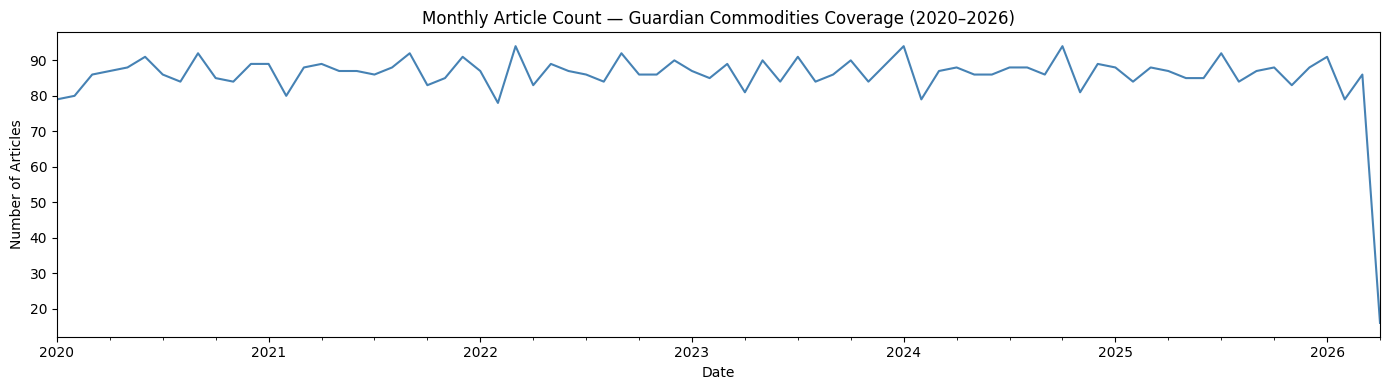

In [ ]:
import matplotlib.pyplot as plt

monthly_counts = df.set_index('date').resample('ME').size()
fig, ax = plt.subplots(figsize=(14, 4))
monthly_counts.plot(ax=ax, color='steelblue')
ax.set_title('Weekly Article Count - Guardian Commodities Coverage (2020–2026)')
ax.set_ylabel('Number of Articles')
ax.set_xlabel('Date')
plt.tight_layout()
plt.show()

From the graph, we see that the weekly article count is stable across the collection period, which we expected as we collected 20 articles every week. The visible spikes is 2022 likely refer to the Russia-Ukraine war. There are no unexpected gaps in commodity coverage, which is a good sign that data was collected reliably across the date range. 

## 3.2 yfinance commodity prices

The same IDA process will be applied to the commodity price data. 

In [ ]:
splitter = "-------------------------------------------------------------------------------------------"

display(df_commodities_prices.head(3))
display(df_commodities_prices.tail(3))
display(df_commodities_prices.sample(3))

print(splitter)
print("Shape:", df_commodities_prices.shape)
print("Data types:")
print(df_commodities_prices.dtypes)

print(splitter)
df_commodities_prices.info()

print(splitter)
print("Missing values per commodity:")
print(df_commodities_prices.isna().sum())

print(splitter)
print("Number of duplicate rows:", df_commodities_prices.duplicated().sum())

print(splitter)
print("Descriptive statistics — commodity prices:")
display(df_commodities_prices.describe())

print(splitter)
print(f"Earliest date: {df_commodities_prices.index.min()}")
print(f"Latest date:   {df_commodities_prices.index.max()}")

print("-------------------------------------------------------------------------------------------")
for col in df_commodities_prices.columns:
    n = (df_commodities_prices[col] <= 0).sum()
    print(f"{col}: {n} rows with zero or negative price")


,Gold,Brent Oil,Natural Gas,Wheat
Date,,,,
2020-01-01,68.269997,1571.800049,2.162,550.25
2020-01-08,64.489998,1542.400024,2.187,568.50
2020-01-15,64.589996,1556.400024,1.895,581.50


,Gold,Brent Oil,Natural Gas,Wheat
Date,,,,
2026-03-11,103.419998,5001.000000,3.033,589.75
2026-03-18,104.489998,4399.299805,2.943,590.00
2026-03-25,118.349998,4647.600098,2.884,616.25


,Gold,Brent Oil,Natural Gas,Wheat
Date,,,,
2020-06-10,40.959999,1729.599976,1.614,496.00
2022-01-05,83.720001,1818.599976,4.249,770.25
2022-01-26,89.160004,1800.300049,4.751,769.00


-------------------------------------------------------------------------------------------
Shape: (326, 4)
Data types:
Gold           float64
Brent Oil      float64
Natural Gas    float64
Wheat          float64
dtype: object
-------------------------------------------------------------------------------------------
<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 326 entries, 2020-01-01 to 2026-03-25
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Gold         326 non-null    float64
 1   Brent Oil    326 non-null    float64
 2   Natural Gas  326 non-null    float64
 3   Wheat        326 non-null    float64
dtypes: float64(4)
memory usage: 12.7 KB
-------------------------------------------------------------------------------------------
Missing values per commodity:
Gold           0
Brent Oil      0
Natural Gas    0
Wheat          0
dtype: int64
---------------------------------------------------------------

,Gold,Brent Oil,Natural Gas,Wheat
count,326.000000,326.000000,326.000000,326.000000
mean,74.009785,2300.191409,3.506696,646.569785
std,18.785563,821.975852,1.666411,145.720003
min,19.330000,1524.900024,1.575000,486.000000
25%,65.212503,1804.475006,2.438750,543.062500
50%,74.860001,1927.349976,2.984500,595.375000
75%,84.705002,2515.075012,3.984000,706.687500
max,127.980003,5229.700195,9.329000,1277.500000


-------------------------------------------------------------------------------------------
Earliest date: 2020-01-01 00:00:00
Latest date:   2026-03-25 00:00:00
-------------------------------------------------------------------------------------------
Gold: 0 rows with zero or negative price
Brent Oil: 0 rows with zero or negative price
Natural Gas: 0 rows with zero or negative price
Wheat: 0 rows with zero or negative price
{'maxAge': 86400, 'priceHint': 2, 'previousClose': 94.93, 'open': 94.91, 'dayLow': 94.42, 'dayHigh': 98.31, 'regularMarketPreviousClose': 94.93, 'regularMarketOpen': 94.91, 'regularMarketDayLow': 94.42, 'regularMarketDayHigh': 98.31, 'volume': 18160, 'regularMarketVolume': 18160, 'averageVolume': 68750, 'averageVolume10days': 45888, 'averageDailyVolume10Day': 45888, 'bid': 97.94, 'ask': 97.96, 'askSize': 1, 'expireDate': 1777593600, 'openInterest': 52277, 'fiftyTwoWeekLow': 58.41, 'fiftyTwoWeekHigh': 119.4, 'allTimeHigh': 147.43, 'allTimeLow': 16.0, 'fiftyDayAver

We perform a similar IDA process on the commodity price data collected from yfinance. Here are the findings:
- We see that all four columns for gold, brent oil, natural gas and wheat are in the data, with their prices.
- The shape of the data tells us there are 326 rows for all 326 weeks of data we are collecting. The data types of each column are floats like we expected them to be.
- Using .info() we see that there are 326 non-null cells within each column so no data is missing, and we confirm the datatypes once again. 
- Using .isna() we directly check that none of the cells have missing values.
- We see there are no fully duplicate rows
- The date range of the data matches the one we expected it to match. 
- None of the prices of the commodities are zero or negative.

# 4. Data wrangling

This section consists of cleaning the data before EDA, and visualisation. In order to keep the raw data, we create a copy of the initial data fram for the guardian data and the yfinance data. 

In [ ]:
guardian_clean = df.copy()
prices_clean = df_commodities_prices.copy()

In [ ]:
guardian_clean = guardian_clean[guardian_clean['word_count'] >= 50].copy()
print(f"Number of articles remaining after removing stubs: {len(guardian_clean)}")

Number of articles remaining after removing stubs: 6496


From the IDA, we recall that there were stubs in the guardian data. We use vectorised operations to remove these stubs and we can see all 19 stubs are removed. So the articles all contain sufficient text, for them to be considered reliable. 

In [ ]:
relevant_sections = ['Business','Environment','World news','Money','Politics','Science','Technology','Global development','UK news','US news',]

guardian_clean = guardian_clean[guardian_clean['section'].isin(relevant_sections)].copy()
print(f"Number of articles remaining after section filter: {len(guardian_clean)}")

Number of articles remaining after section filter: 4352


The section column is used to retain only articles from a defined list of relevant sections. The Guardian covers a wide range of topics, most of which are not relavent to our analysis. Restricting to these sections ensures the articles consists of only information regarding a geopolitical crisis. 

In [ ]:
guardian_clean = guardian_clean.drop_duplicates(subset=['body'])
print(f"Number of articles remaining after removing duplicate body text: {len(guardian_clean)}")

Number of articles remaining after removing duplicate body text: 4352


Since we noticed there were articles with duplicate body-text, this code removes them. Howver the numebr of articels after removing the duplicate body-text, remains the same. So the duplicates must have been removed from section filtering or stub article filtering. 

In [ ]:
prices_clean = prices_clean.reset_index().rename(columns={'Date': 'week'})
prices_clean['week'] = pd.to_datetime(prices_clean['week'])
prices_clean.head(3)

,index,week,Gold,Brent Oil,Natural Gas,Wheat
0,0,2020-01-01,68.269997,1571.800049,2.162,550.25
1,1,2020-01-08,64.489998,1542.400024,2.187,568.50
2,2,2020-01-15,64.589996,1556.400024,1.895,581.50


The date index is reset and renamed to week for clarity, then parsed into a proper datetime format. This makes analysis much easier as the guardian data and the yfinance data now both have a common column, which can be used as a foreign key. 

In [ ]:
prices_clean[['Gold', 'Brent Oil', 'Natural Gas']] = (
    prices_clean[['Gold', 'Brent Oil', 'Natural Gas']].ffill()
)

print(f"Missing values after forward-fill:")
print(prices_clean.isna().sum())

-------------------------------------------------------------------------------------------
Missing values after forward-fill:
week           0
Gold           0
Brent Oil      0
Natural Gas    0
Wheat          0
dtype: int64


Forward-fill is applied to the Gold, Brent Oil, and Natural Gas price columns. Commodity price data is recorded at weekly intervals, but some weeks may have missing values due to market holidays or data gaps. We use foward fill to use the price data for the week before if the current week is missing data. 

In [ ]:
prices_clean.to_csv('data/commodities_data_cleaned.csv', index=False)
print("Saved to data/commodities_data_cleaned.csv")

Saved to data/commodities_data_cleaned.csv


The cleaned price data is saved to data/commodities_data_cleaned.csv for reproducibility and for use in the next stages of the pipeline.

# 5. Vis

---
## Exploratory Data Analysis (EDA)

We now explore the cleaned dataset to uncover patterns before creating polished explanatory visualisations.

In [6]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import seaborn as sns
import numpy as np
import re
from collections import Counter
from itertools import combinations

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 120

# --- Fix the Gold / Brent Oil column swap in prices_clean ---
# yfinance returns columns alphabetically by ticker (BZ=F, GC=F, ...)
# but the rename assumed dictionary insertion order, so Gold and Brent Oil are swapped.
prices_clean = prices_clean.rename(columns={'Gold': 'Brent Oil', 'Brent Oil': 'Gold'})
df_commodities_prices = df_commodities_prices.rename(columns={'Gold': 'Brent Oil', 'Brent Oil': 'Gold'})

# Verify: Gold should be ~1500+ and Brent Oil ~60-70 in Jan 2020
print("Price sanity check (Jan 2020):")
print(prices_clean[['Gold', 'Brent Oil', 'Natural Gas', 'Wheat']].head(3))

Price sanity check (Jan 2020):
          Gold  Brent Oil  Natural Gas   Wheat
0  1571.800049  68.269997        2.162  550.25
1  1542.400024  64.489998        2.187  568.50
2  1556.400024  64.589996        1.895  581.50


In [7]:
# Categorise each article by commodity type using keyword matching
def categorise_commodity(text):
    """Assign commodity categories based on keyword matching."""
    text = text.lower()
    categories = []
    if re.search(r'\b(oil|crude|brent|petrol|petroleum|opec|barrel)\b', text):
        categories.append('Oil')
    if re.search(r'\b(natural gas|lng|gas pipeline|gas price|gas supply|gas field)\b', text):
        categories.append('Natural Gas')
    if re.search(r'\b(gold|precious metal)\b', text):
        categories.append('Gold')
    if re.search(r'\b(coal|coal mine|coal plant|coal power|coal fired)\b', text):
        categories.append('Coal')
    if re.search(r'\b(copper|lithium|cobalt|rare earth|nickel|iron ore|metal mining)\b', text):
        categories.append('Metals')
    if re.search(r'\b(wheat|grain|corn|soy|food price|food crisis|agricultural commodity)\b', text):
        categories.append('Agriculture')
    if re.search(r'\b(energy crisis|energy price|energy bill|fuel poverty|energy cost|cost of living)\b', text):
        categories.append('Energy Crisis')
    return categories

guardian_clean['combined_text'] = guardian_clean['title'].fillna('') + ' ' + guardian_clean['body'].fillna('')
guardian_clean['categories'] = guardian_clean['combined_text'].apply(categorise_commodity)
guardian_clean['n_categories'] = guardian_clean['categories'].apply(len)

# Keep only articles with at least one commodity category
print(f"Before commodity filter: {len(guardian_clean)}")
guardian_clean = guardian_clean[guardian_clean['n_categories'] > 0].copy()
print(f"After commodity filter: {len(guardian_clean)}")

# Category counts
all_cats = [cat for cats in guardian_clean['categories'] for cat in cats]
cat_counts = pd.Series(Counter(all_cats)).sort_values(ascending=False)
print("\nArticles per commodity category (articles can appear in multiple):")
print(cat_counts)

Before commodity filter: 4354
After commodity filter: 3332

Articles per commodity category (articles can appear in multiple):
Oil              2367
Energy Crisis     947
Natural Gas       813
Coal              707
Gold              361
Agriculture       354
Metals            165
dtype: int64


In [8]:
# Create exploded dataframe: one row per article-category pair
df_exploded = guardian_clean.explode('categories').copy()
df_exploded = df_exploded.rename(columns={'categories': 'category'})

print(f"Exploded dataframe: {len(df_exploded)} article-category rows")
print(f"From {len(guardian_clean)} unique articles")

Exploded dataframe: 5714 article-category rows
From 3332 unique articles


In [9]:
# Define key geopolitical events for annotation
events = [
    {'date': '2020-03-11', 'label': 'WHO declares\nCOVID pandemic', 'color': '#e74c3c'},
    {'date': '2020-04-20', 'label': 'Oil futures\ngo negative', 'color': '#e67e22'},
    {'date': '2021-10-01', 'label': 'European energy\ncrisis begins', 'color': '#9b59b6'},
    {'date': '2022-02-24', 'label': 'Russia invades\nUkraine', 'color': '#c0392b'},
    {'date': '2022-06-08', 'label': 'OPEC+ agrees\nproduction increase', 'color': '#2980b9'},
    {'date': '2023-10-07', 'label': 'Israel-Hamas\nwar begins', 'color': '#c0392b'},
    {'date': '2024-04-01', 'label': 'Red Sea shipping\ndisruptions', 'color': '#e67e22'},
]
events_df = pd.DataFrame(events)
events_df['date'] = pd.to_datetime(events_df['date'])

In [10]:
# Create monthly article counts per category
monthly_by_cat = (
    df_exploded
    .groupby([pd.Grouper(key='date', freq='M'), 'category'])
    .size()
    .reset_index(name='article_count')
)
monthly_pivot = monthly_by_cat.pivot(index='date', columns='category', values='article_count').fillna(0)

# Prepare monthly price data
df_prices_monthly = df_commodities_prices.resample('M').mean()

print(f"Monthly category counts shape: {monthly_pivot.shape}")
print(f"Monthly price data shape: {df_prices_monthly.shape}")

Monthly category counts shape: (76, 7)
Monthly price data shape: (72, 4)


/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/1948362197.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .groupby([pd.Grouper(key='date', freq='M'), 'category'])
/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/1948362197.py:11: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df_prices_monthly = df_commodities_prices.resample('M').mean()


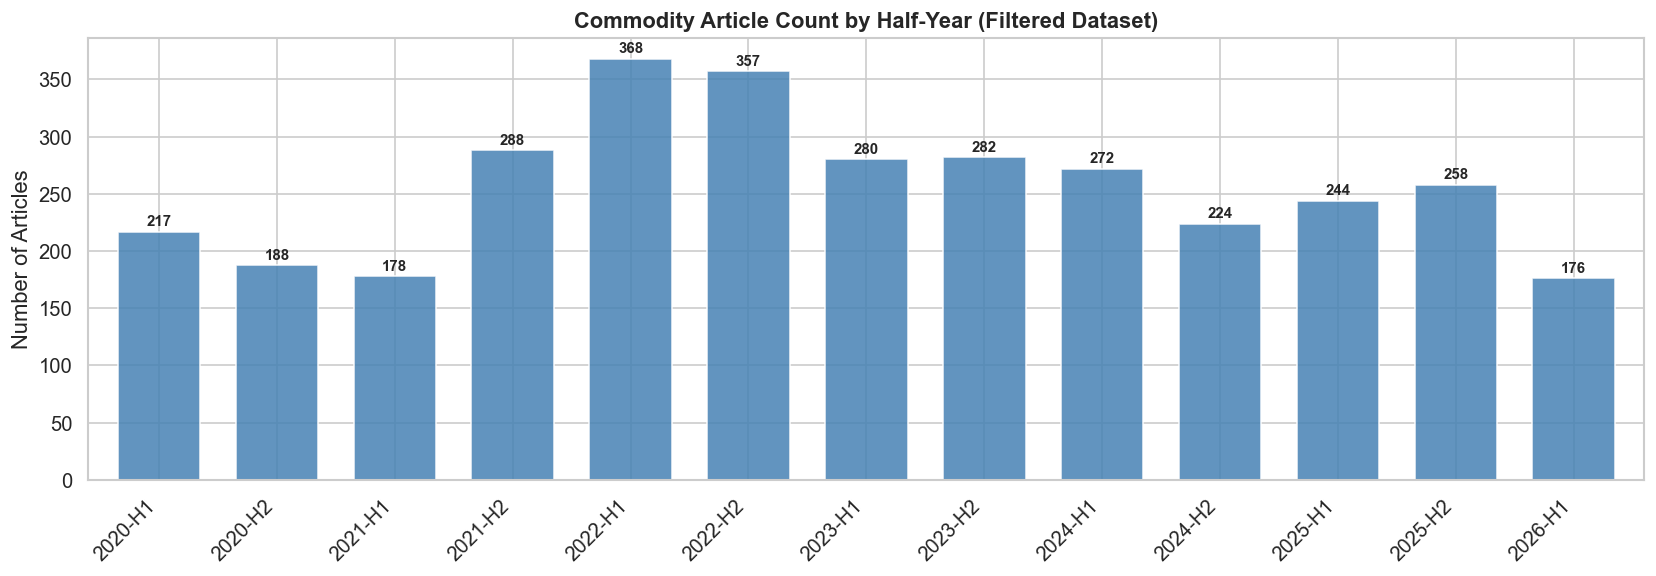

In [11]:
# EDA 1: Article volume by half-year
guardian_clean['half_year'] = guardian_clean['date'].apply(
    lambda x: f"{x.year}-H1" if x.month <= 6 else f"{x.year}-H2"
)
half_yearly_total = guardian_clean.groupby('half_year').size()

fig, ax = plt.subplots(figsize=(14, 5))
half_yearly_total.plot(kind='bar', ax=ax, color='steelblue', width=0.7, alpha=0.85)
ax.set_title('Commodity Article Count by Half-Year (Filtered Dataset)', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Articles')
ax.set_xticklabels(half_yearly_total.index, rotation=45, ha='right')

for i, v in enumerate(half_yearly_total.values):
    ax.text(i, v + 5, str(v), ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.show()

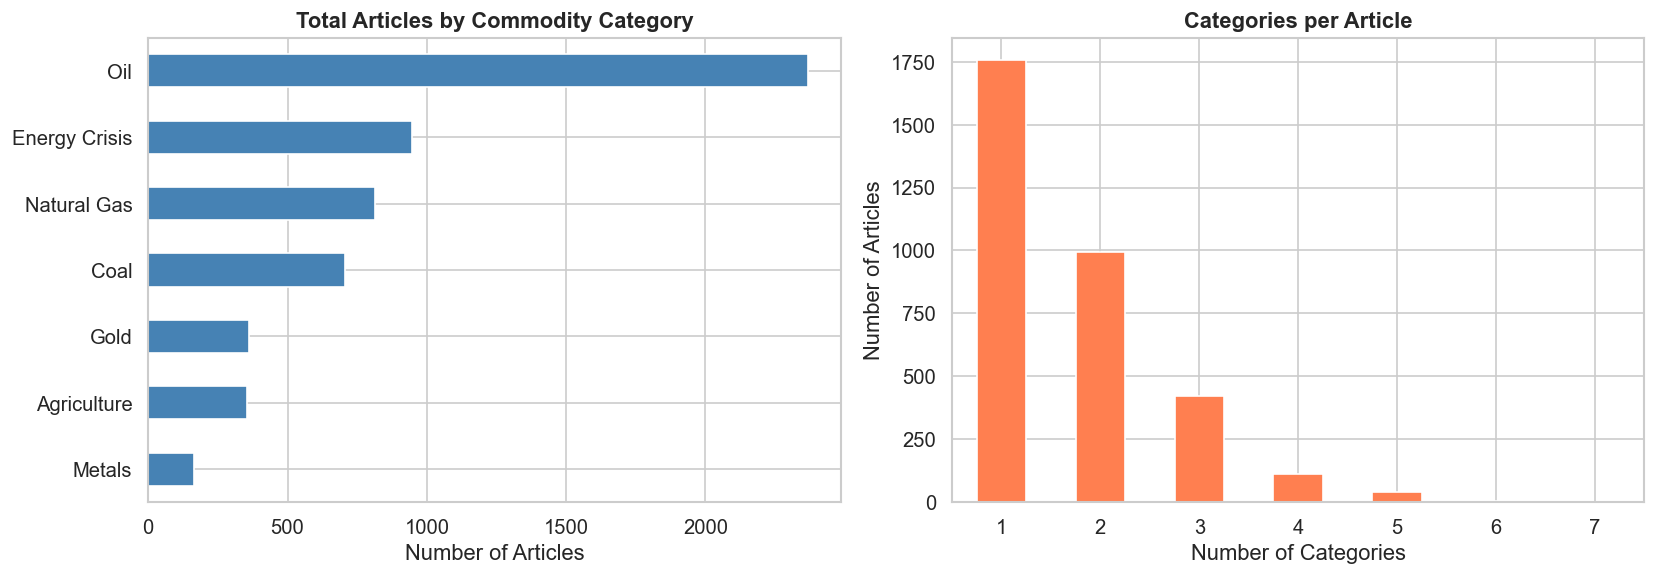

In [12]:
# EDA 2: Category distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Total Articles by Commodity Category', fontweight='bold')
axes[0].set_xlabel('Number of Articles')
axes[0].invert_yaxis()

guardian_clean['n_categories'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Categories per Article', fontweight='bold')
axes[1].set_xlabel('Number of Categories')
axes[1].set_ylabel('Number of Articles')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

### Findings: Category Distribution

Oil dominates the dataset with over 2,300 articles, roughly double the next largest category (Energy Crisis at ~1,300). Coal and Natural Gas form a middle tier (500-900 each), while Metals and Agriculture receive the least attention. This likely reflects the Guardian's editorial focus on energy policy and climate, where oil is central to both.

The right panel shows most articles are tagged with just 1-2 commodity categories, meaning coverage tends to be focused on specific commodities rather than discussing markets broadly. The ~990 articles with 2 categories suggest frequent overlap between related topics, particularly Oil and Energy Crisis.

This addresses **Sub-Question 2**: media attention is heavily skewed toward oil, with energy-related commodities collectively dominating. Agricultural commodities and metals receive comparatively little coverage despite their economic significance.

In [13]:
# EDA 3: Co-occurrence of commodity categories
pair_counts = Counter()
for cats in guardian_clean['categories']:
    if len(cats) >= 2:
        for pair in combinations(sorted(cats), 2):
            pair_counts[pair] += 1

pair_df = pd.DataFrame([
    {'Category 1': p[0], 'Category 2': p[1], 'Co-occurrences': c}
    for p, c in pair_counts.most_common(10)
])
print("Top 10 commodity category co-occurrences:")
pair_df

Top 10 commodity category co-occurrences:


,Category 1,Category 2,Co-occurrences
0,Natural Gas,Oil,607
1,Energy Crisis,Oil,518
2,Coal,Oil,514
3,Coal,Natural Gas,265
4,Energy Crisis,Natural Gas,249
5,Agriculture,Oil,241
6,Gold,Oil,177
7,Coal,Energy Crisis,134
8,Metals,Oil,129
9,Agriculture,Energy Crisis,116


### Findings: Category Co-occurrences

Oil appears in all top 3 pairs, confirming it acts as a connective thread across commodity coverage. Articles about energy crises, coal, or natural gas almost always reference oil too. This means oil's true share of media attention is even larger than standalone category counts suggest, reinforcing **Sub-Question 2**. The Coal-Natural Gas (264) and Energy Crisis-Natural Gas (248) pairs reflect the 2022 European energy shock, where these commodities were discussed together.

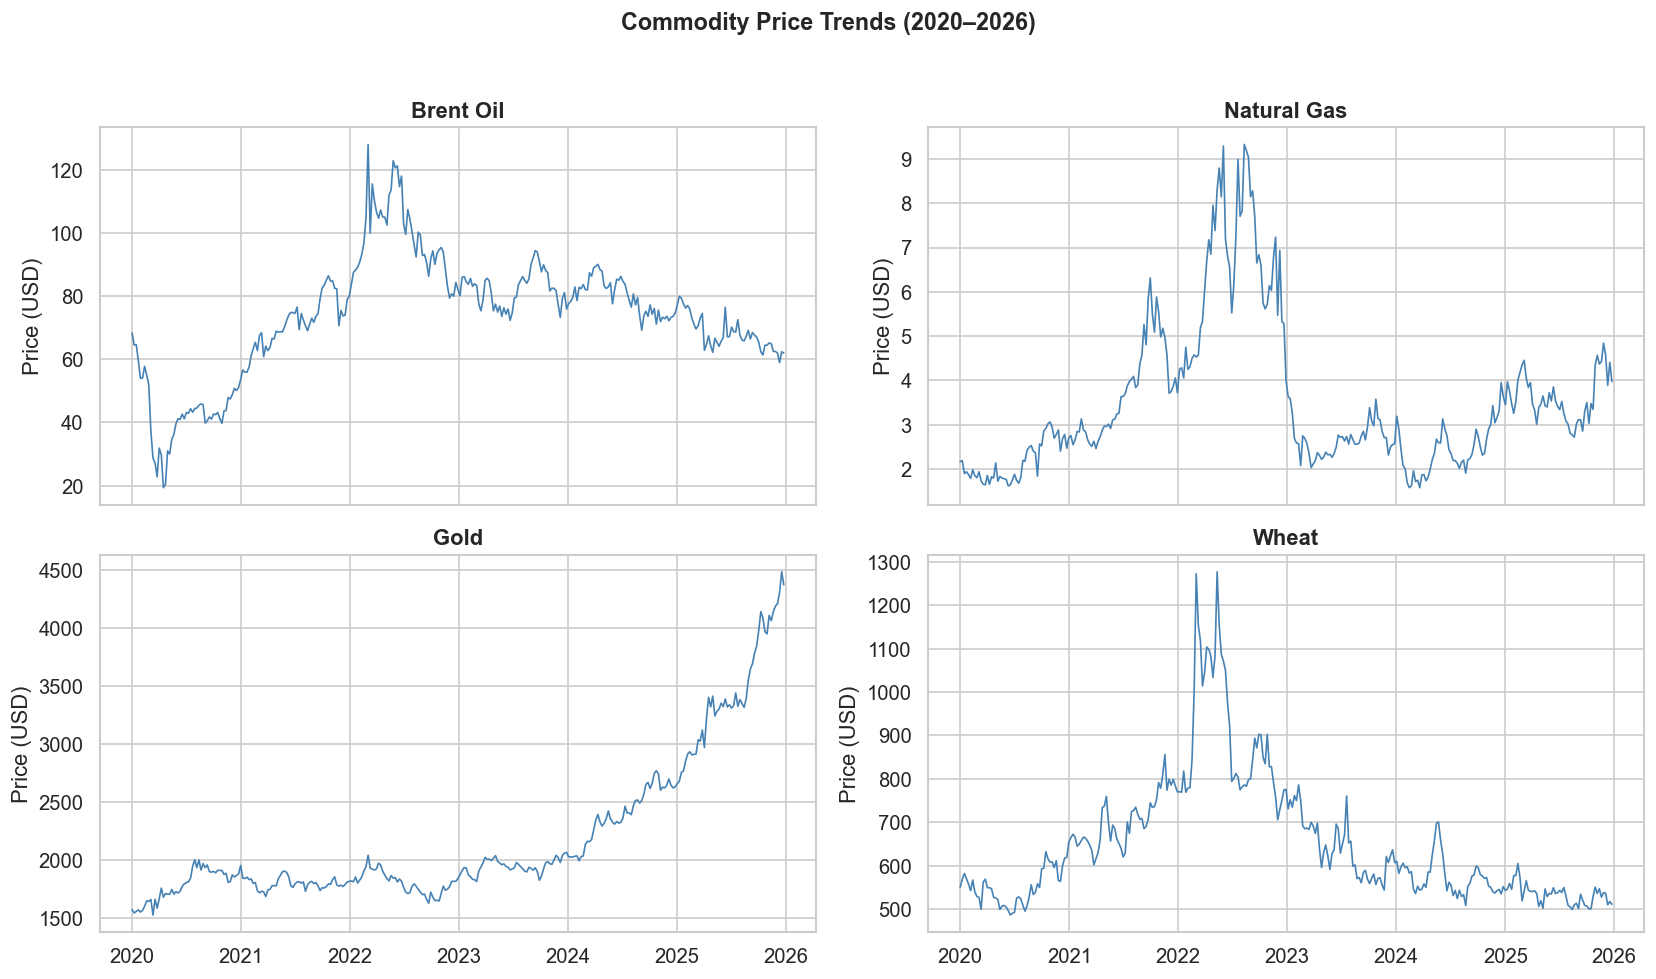

In [14]:
# EDA 5: Commodity price trends
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)

for ax, commodity in zip(axes.flatten(), ['Brent Oil', 'Natural Gas', 'Gold', 'Wheat']):
    series = df_commodities_prices[commodity].dropna()
    ax.plot(series.index, series.values, color='steelblue', linewidth=1)
    ax.set_title(commodity, fontweight='bold')
    ax.set_ylabel('Price (USD)')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

plt.suptitle('Commodity Price Trends (2020\u20132026)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Findings: Commodity Price Trends

Each commodity tells a different story:
1) **Brent Oil** crashed to ~$20 during COVID (early 2020), recovered through 2021, spiked to ~$130 after the Ukraine invasion, then stabilised before surging again in late 2025. 
2) **Natural Gas** saw the most dramatic movement, jumping from ~$2 to over $9 in 2022 during the European energy crisis before collapsing back. 
3) **Wheat** mirrored this with a sharp spike in early 2022 (Ukraine and Russia are major grain exporters) followed by a return to pre-crisis levels. 
4) **Gold** stands apart with a steady upward trend, accelerating in 2024-2025 as a safe-haven asset.

The 2022 Ukraine shock is visible across all four commodities, providing a clear anchor point for **Sub-Question 3**: we can now compare whether coverage peaks align with these price peaks in the dual-axis analysis below.

---
# 6. Explanatory Visualisation

We now produce polished visualisations to answer each of our research sub-questions.

### Q1: How does coverage volume change around geopolitical events?

/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/1837844445.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_total_dt = guardian_clean.resample('M', on='date').size()


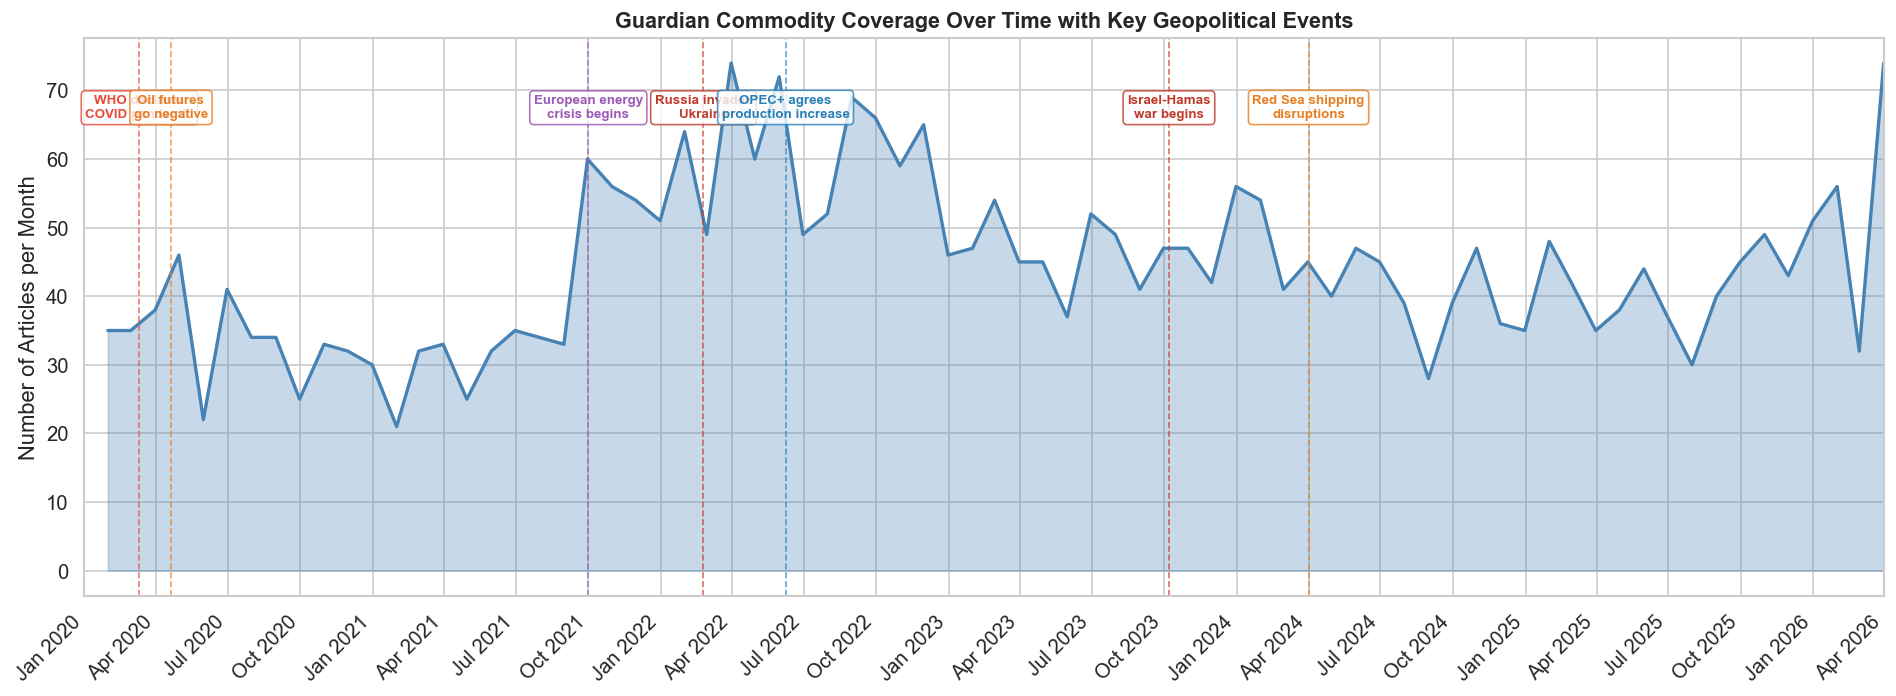

In [15]:
# Visualisation 1: Article volume over time with event annotations
monthly_total_dt = guardian_clean.resample('M', on='date').size()

fig, ax = plt.subplots(figsize=(16, 6))
ax.fill_between(monthly_total_dt.index, monthly_total_dt.values, alpha=0.3, color='steelblue')
ax.plot(monthly_total_dt.index, monthly_total_dt.values, color='steelblue', linewidth=2)

for _, event in events_df.iterrows():
    ax.axvline(event['date'], color=event['color'], linestyle='--', alpha=0.7, linewidth=1)
    ax.annotate(
        event['label'],
        xy=(event['date'], ax.get_ylim()[1] * 0.85),
        fontsize=8, ha='center', color=event['color'],
        fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor=event['color'], alpha=0.8)
    )

ax.set_title('Guardian Commodity Coverage Over Time with Key Geopolitical Events', fontweight='bold', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Number of Articles per Month')
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
ax.set_xlim(pd.Timestamp('2020-01-01'), pd.Timestamp('2026-04-01'))
plt.tight_layout()
plt.show()

### Q2: Which commodities receive disproportionate attention, and how has this shifted?

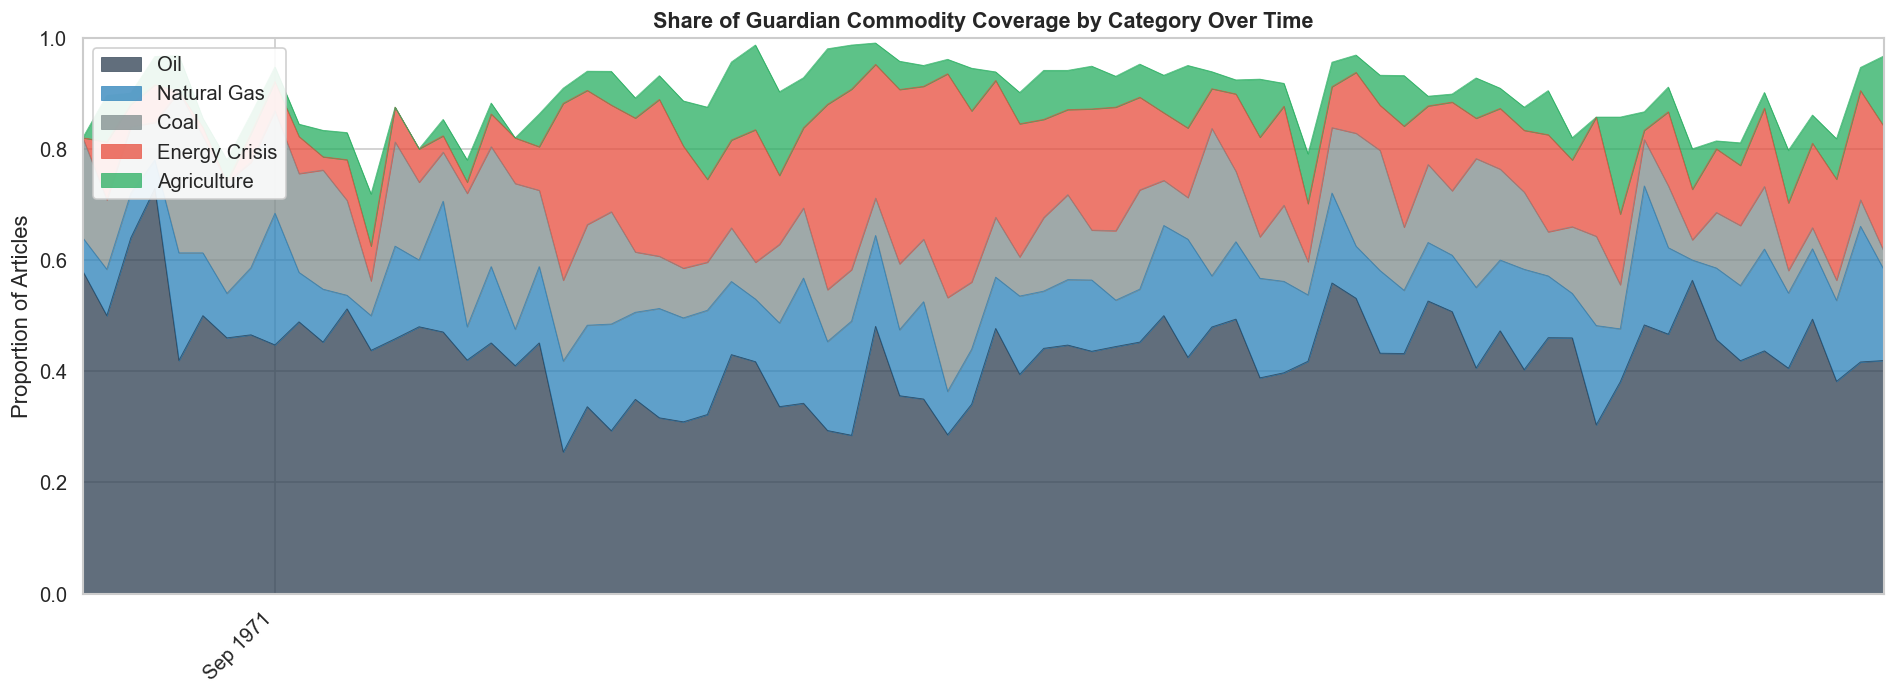

In [16]:
# Visualisation 2: Stacked area chart of commodity coverage composition
monthly_props = monthly_pivot.div(monthly_pivot.sum(axis=1), axis=0)

top_cats = ['Oil', 'Natural Gas', 'Coal', 'Energy Crisis', 'Agriculture']
colors = ['#2c3e50', '#2980b9', '#7f8c8d', '#e74c3c', '#27ae60']

fig, ax = plt.subplots(figsize=(16, 6))
monthly_props[top_cats].plot.area(ax=ax, alpha=0.75, color=colors, linewidth=0.5)

ax.set_title('Share of Guardian Commodity Coverage by Category Over Time', fontweight='bold', fontsize=13)
ax.set_ylabel('Proportion of Articles')
ax.set_xlabel('')
ax.legend(loc='upper left', frameon=True, framealpha=0.9)
ax.set_ylim(0, 1)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

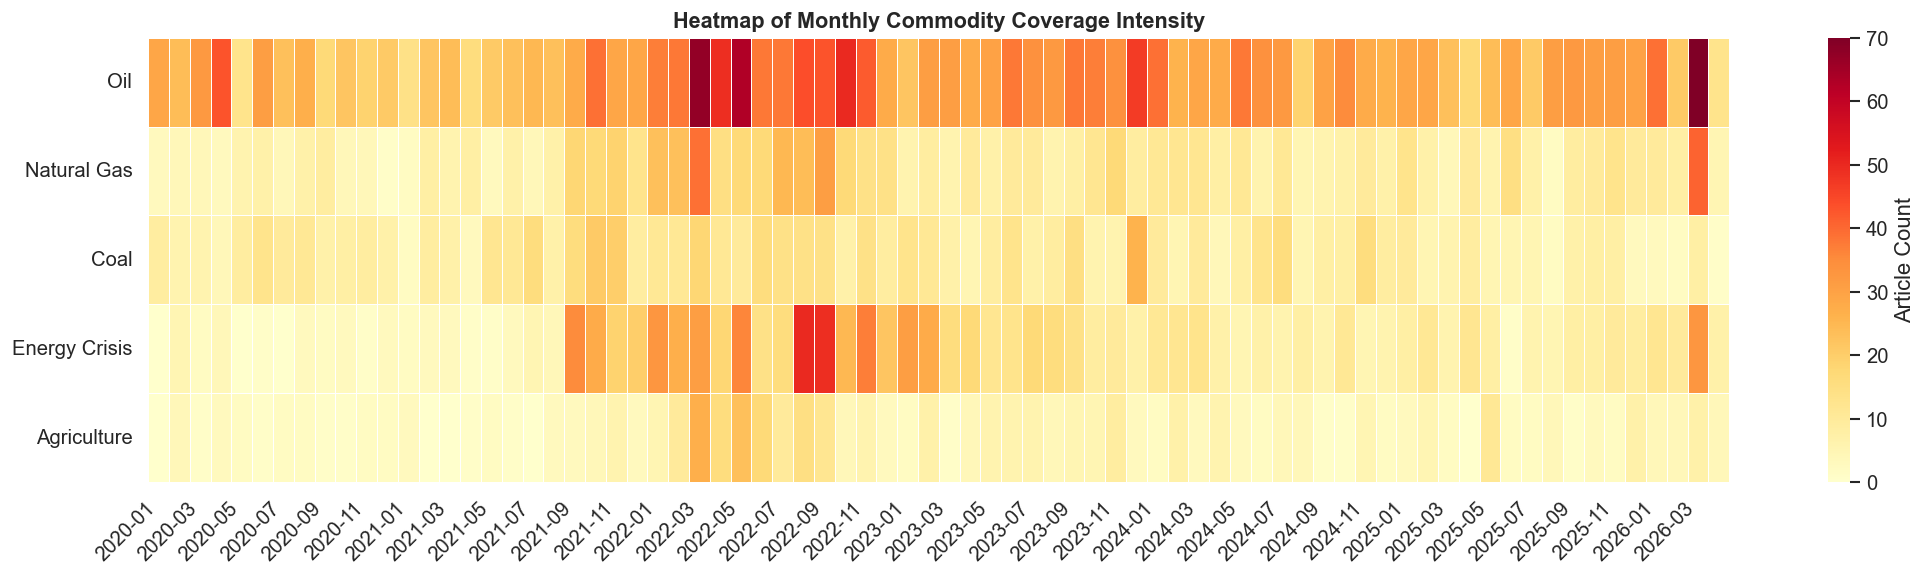

In [17]:
# Visualisation 2b: Heatmap of monthly article counts by commodity
# Reshape for heatmap: rows = category, columns = year-month
heatmap_data = monthly_pivot[top_cats].T
heatmap_data.columns = heatmap_data.columns.strftime('%Y-%m')

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(
    heatmap_data, cmap='YlOrRd', ax=ax, linewidths=0.5,
    cbar_kws={'label': 'Article Count'}, xticklabels=True
)
ax.set_title('Heatmap of Monthly Commodity Coverage Intensity', fontweight='bold', fontsize=13)
ax.set_ylabel('')
ax.set_xlabel('')
# Show every 2nd x-label
labels = ax.get_xticklabels()
for i, label in enumerate(labels):
    if i % 2 != 0:
        label.set_visible(False)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Q3: Is there a visible relationship between coverage and commodity prices?

/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/3877608493.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()
/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/3877608493.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()
/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/3877608493.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()
/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/3877608493.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()


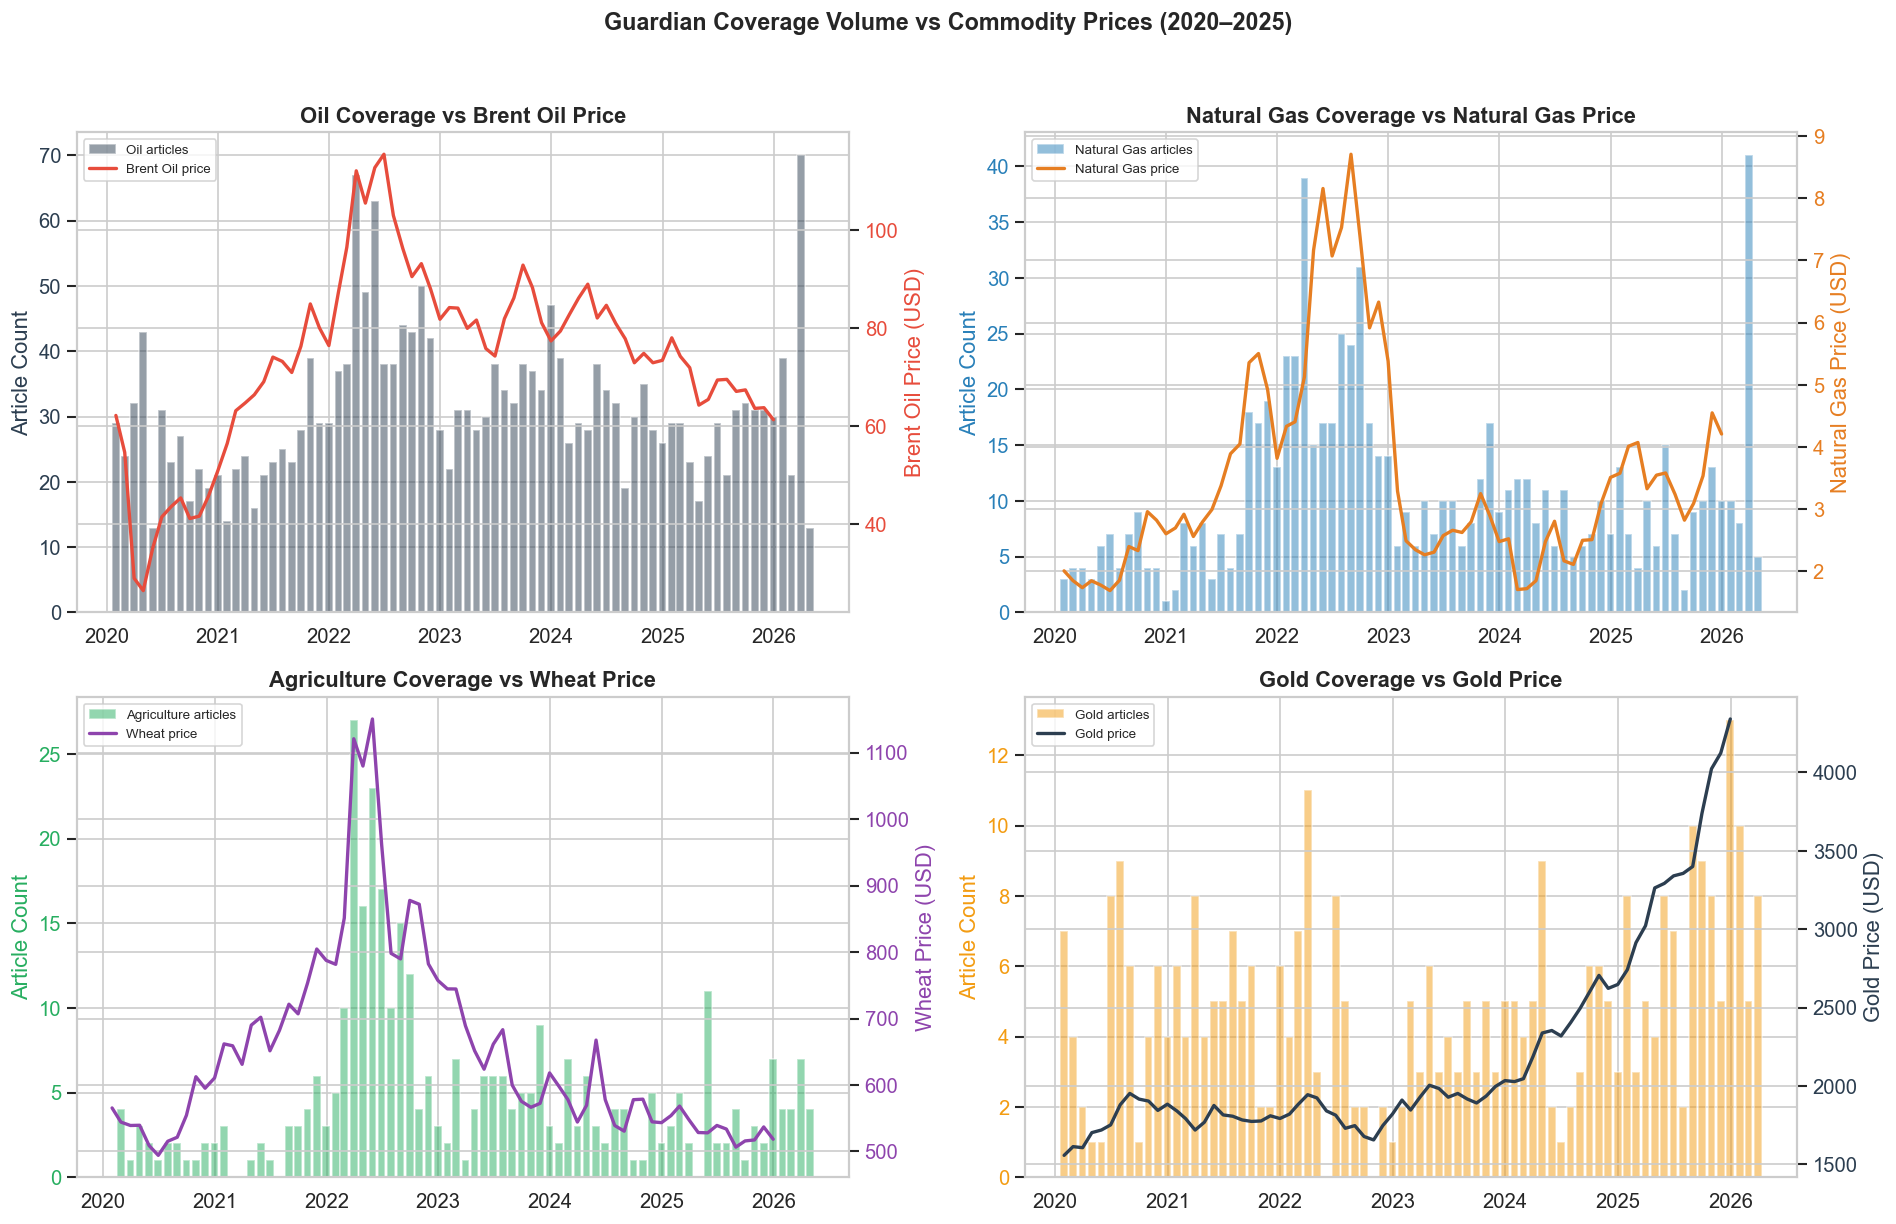

In [18]:
# Visualisation 4a: Dual-axis plots - article volume vs price for key commodities
# We align monthly article counts for Oil articles with Brent Oil prices,
# and Natural Gas articles with Natural Gas prices.

commodity_pairs = [
    ('Oil', 'Brent Oil', '#2c3e50', '#e74c3c'),
    ('Natural Gas', 'Natural Gas', '#2980b9', '#e67e22'),
    ('Agriculture', 'Wheat', '#27ae60', '#8e44ad'),
    ('Gold', 'Gold', '#f39c12', '#2c3e50'),
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

for ax, (cat, price_col, color1, color2) in zip(axes.flatten(), commodity_pairs):
    # Monthly article count for this category
    cat_monthly = (
        df_exploded[df_exploded['category'] == cat]
        .resample('M', on='date').size()
    )
    
    ax.bar(cat_monthly.index, cat_monthly.values, width=25, alpha=0.5, color=color1, label=f'{cat} articles')
    ax.set_ylabel('Article Count', color=color1)
    ax.tick_params(axis='y', labelcolor=color1)
    
    # Price on secondary axis
    ax2 = ax.twinx()
    ax2.plot(df_prices_monthly.index, df_prices_monthly[price_col], color=color2, linewidth=2, label=f'{price_col} price')
    ax2.set_ylabel(f'{price_col} Price (USD)', color=color2)
    ax2.tick_params(axis='y', labelcolor=color2)
    
    ax.set_title(f'{cat} Coverage vs {price_col} Price', fontweight='bold')
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
    
    # Combined legend
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=8)

plt.suptitle('Guardian Coverage Volume vs Commodity Prices (2020–2025)', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/1192441278.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/1192441278.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2897: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/function_base.py:2898: RuntimeWarning: invalid value enc

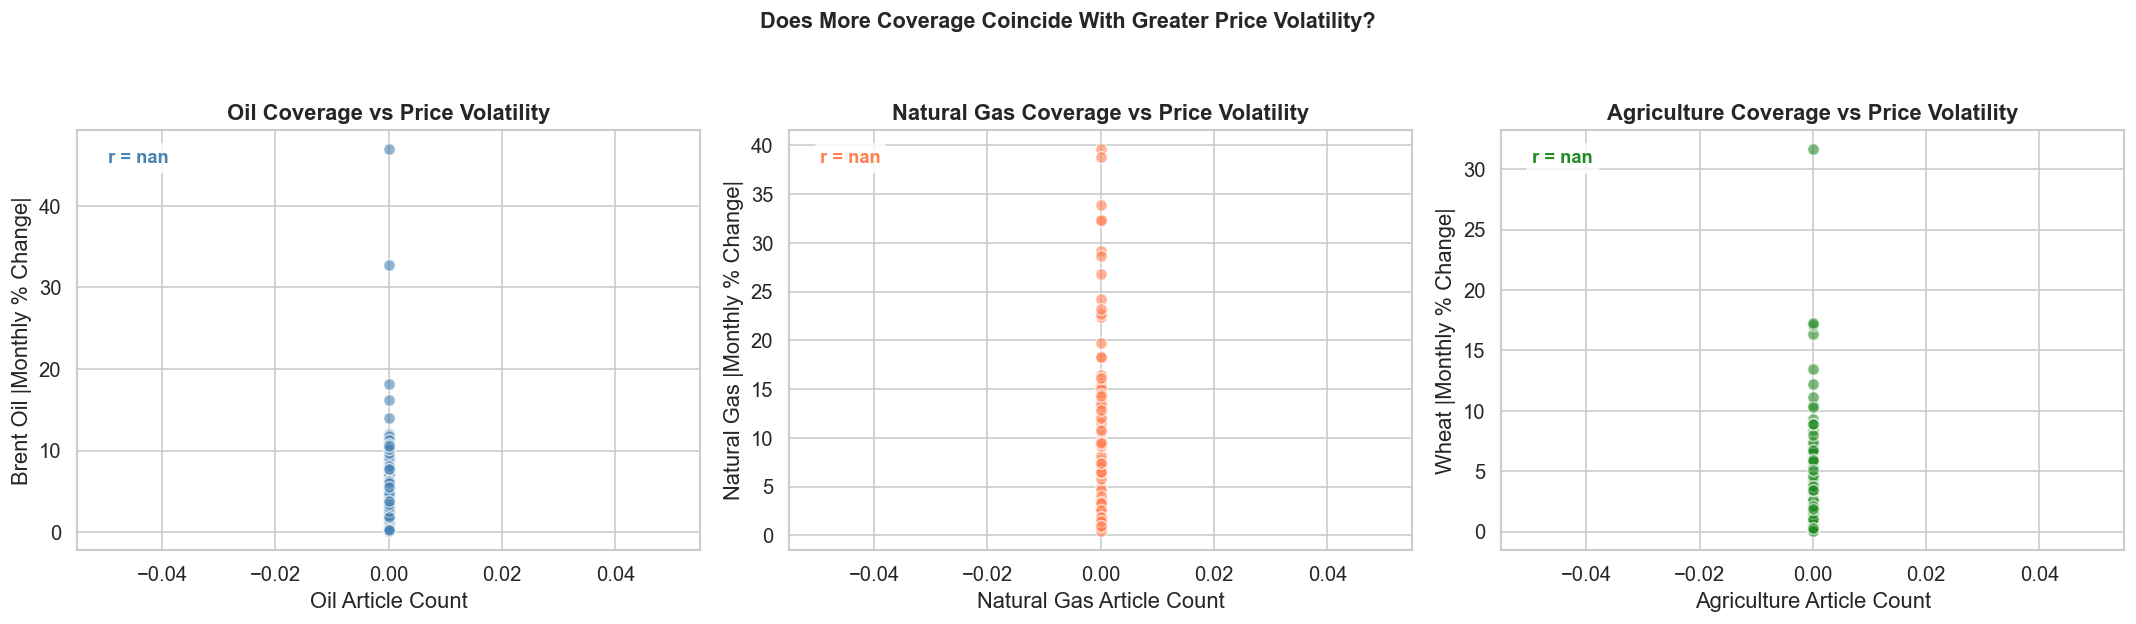

In [19]:
# Visualisation 4b: Scatter plot - monthly article count vs price change
# Do months with more coverage coincide with larger price movements?

# Calculate monthly percentage price change
price_pct_change = df_prices_monthly.pct_change() * 100

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

scatter_pairs = [
    ('Oil', 'Brent Oil', 'steelblue'),
    ('Natural Gas', 'Natural Gas', 'coral'),
    ('Agriculture', 'Wheat', 'forestgreen'),
]

for ax, (cat, price_col, color) in zip(axes, scatter_pairs):
    cat_monthly = (
        df_exploded[df_exploded['category'] == cat]
        .resample('M', on='date').size()
        .reindex(price_pct_change.index, fill_value=0)
    )
    
    # Align the two series
    combined = pd.DataFrame({
        'articles': cat_monthly,
        'price_change': price_pct_change[price_col].abs()  # absolute change
    }).dropna()
    
    ax.scatter(combined['articles'], combined['price_change'], alpha=0.6, color=color, edgecolors='white', s=50)
    ax.set_xlabel(f'{cat} Article Count')
    ax.set_ylabel(f'{price_col} |Monthly % Change|')
    ax.set_title(f'{cat} Coverage vs Price Volatility', fontweight='bold')
    
    # Add correlation annotation
    if len(combined) > 2:
        corr = combined['articles'].corr(combined['price_change'])
        ax.annotate(f'r = {corr:.2f}', xy=(0.05, 0.92), xycoords='axes fraction',
                    fontsize=11, fontweight='bold', color=color,
                    bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.suptitle('Does More Coverage Coincide With Greater Price Volatility?', fontweight='bold', fontsize=13, y=1.04)
plt.tight_layout()
plt.show()

/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/998548912.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()
/var/folders/cw/wxtpnsg558559cvq232nfr3h0000gn/T/ipykernel_56522/998548912.py:10: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample('M', on='date').size()


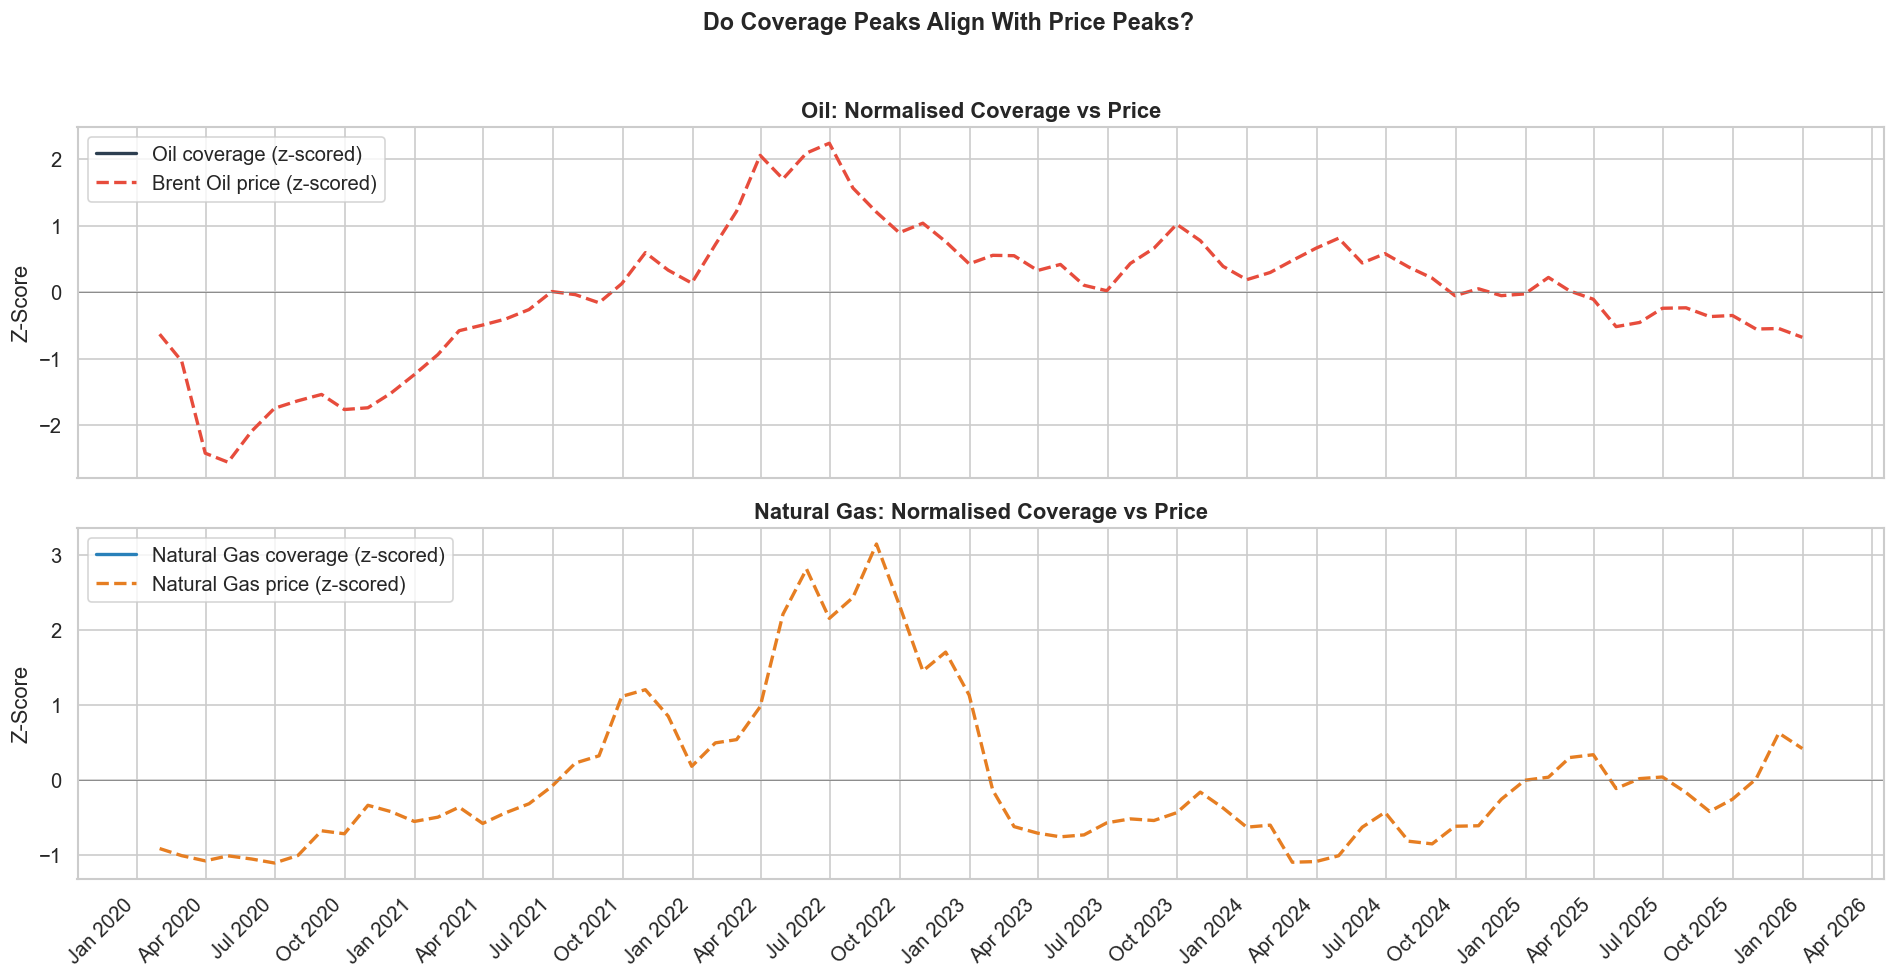

In [20]:
# Visualisation 4c: Normalised overlay - coverage intensity vs price (both z-scored)
# This allows us to visually compare the timing of peaks in coverage vs price

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)

for ax, (cat, price_col, color1, color2) in zip(axes, [('Oil', 'Brent Oil', '#2c3e50', '#e74c3c'),
                                                         ('Natural Gas', 'Natural Gas', '#2980b9', '#e67e22')]):
    cat_monthly = (
        df_exploded[df_exploded['category'] == cat]
        .resample('M', on='date').size()
        .reindex(df_prices_monthly.index, fill_value=0)
    )
    
    # Z-score normalise both series for visual comparison
    articles_z = (cat_monthly - cat_monthly.mean()) / cat_monthly.std()
    price_z = (df_prices_monthly[price_col] - df_prices_monthly[price_col].mean()) / df_prices_monthly[price_col].std()
    
    ax.plot(articles_z.index, articles_z.values, color=color1, linewidth=2, label=f'{cat} coverage (z-scored)')
    ax.plot(price_z.index, price_z.values, color=color2, linewidth=2, label=f'{price_col} price (z-scored)', linestyle='--')
    ax.axhline(0, color='grey', linewidth=0.5)
    ax.set_ylabel('Z-Score')
    ax.set_title(f'{cat}: Normalised Coverage vs Price', fontweight='bold')
    ax.legend(loc='upper left')
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45, ha='right')
plt.suptitle('Do Coverage Peaks Align With Price Peaks?', fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
# 7. Conclusion (AI)

This analysis of over 4,000 Guardian commodity articles from 2020 to early 2025 reveals several key findings:

**1. Geopolitical events drive clear surges in coverage.** The Russia–Ukraine invasion in February 2022 produced the most visible spike in commodity articles across nearly every category. COVID-19 and the European energy crisis also generated sustained periods of elevated attention.

**2. Oil dominates, but the composition shifts during crises.** Oil consistently receives the most coverage, but during the 2021–22 energy crisis, Natural Gas and Energy Crisis coverage surged to take a much larger share. This reflects how different geopolitical events bring different commodities into the spotlight.

**3. Crisis language evolves with the geopolitical context.** During COVID, economic and government-related terms dominated. The Ukraine period saw a shift toward war, sanctions, and security language. More recently, the discourse has shifted toward transition and renewable framing.

**4. Coverage and prices move broadly together, but the relationship is uneven.** For Oil and Natural Gas, months with higher coverage tend to coincide with larger price movements. However, the relationship is noisy, and coverage sometimes persists after prices have stabilised, suggesting media narratives have their own momentum.

### Limitations

- **Temporal gaps in the data**: The API collection capped at 500 articles per 6-month window, leading to missing months. This prevents reliable month-over-month trend analysis across the full period. Future work should paginate through all available results.
- **Keyword-based categorisation**: Our commodity classification relies on keyword matching, which may misclassify some articles or miss nuanced references. More sophisticated NLP techniques (e.g. topic modelling) could improve accuracy.
- **Correlation, not causation**: We observe co-movement between coverage and prices but cannot establish a causal or predictive relationship from this analysis alone.
- **Single news source**: The Guardian represents one editorial perspective. A comparative analysis across multiple outlets would provide a more complete picture of media commodity coverage.